In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_dataset(): 
    df = pd.read_csv('Housing.csv') 
    print(df)
    return df
df = load_dataset()


        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

In [2]:
def summary(df):   
    print(df.head())  
    print(df.info())  
    print(df.dtypes)  
    print(df.describe())  
    print(df.shape)   
    
summary(df)

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

In [3]:
print('Missing values:')  
print(df.isnull().sum())

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [4]:
print('Duplicates')
print(df.duplicated().sum())

Duplicates
0


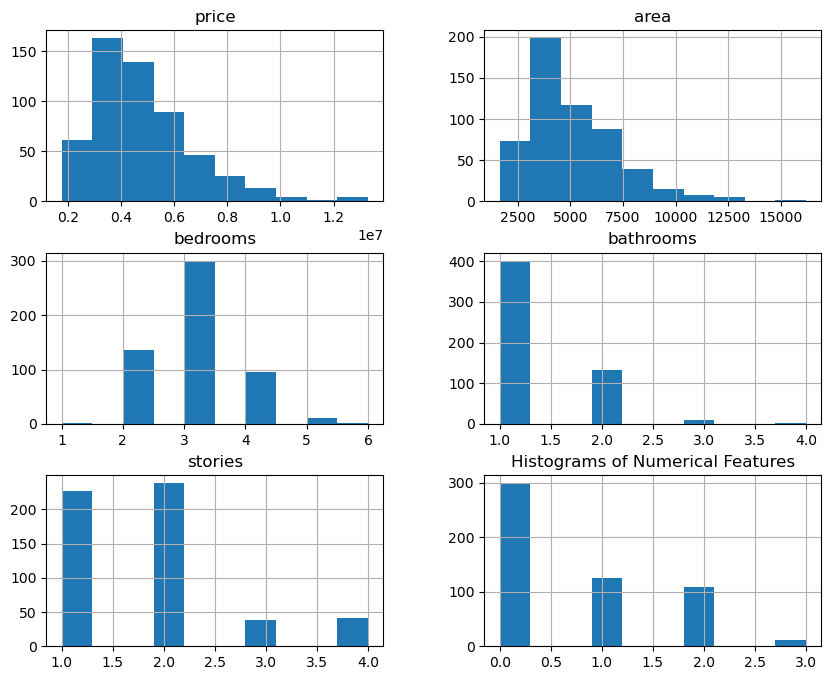

In [5]:
# Univariate analysis
# Histogram for numerical columns

df.hist(figsize=(10, 8))
plt.title('Histograms of Numerical Features')
plt.show()


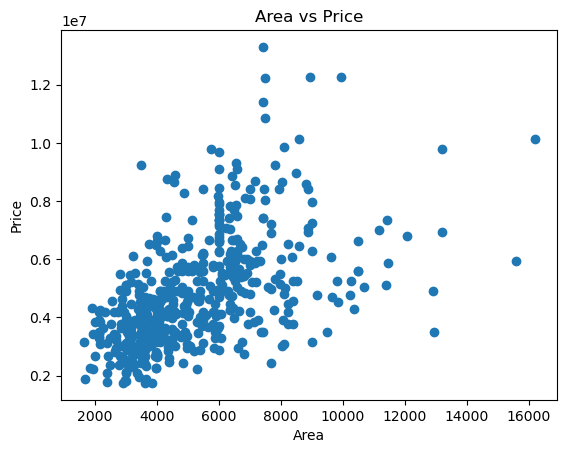

In [6]:
# Bivariate Analysis
plt.scatter(df['area'], df['price'])
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [7]:
# Feature Engineering

cols = ['mainroad','guestroom','basement','hotwaterheating',
        'airconditioning','prefarea']

for col in cols:
    df[col] = df[col].map({'yes':1, 'no':0})

In [8]:
# New features 
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['price_per_sqft'] = df['price'] / df['area']

In [10]:
# Converting furnishingstatus using one-hot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

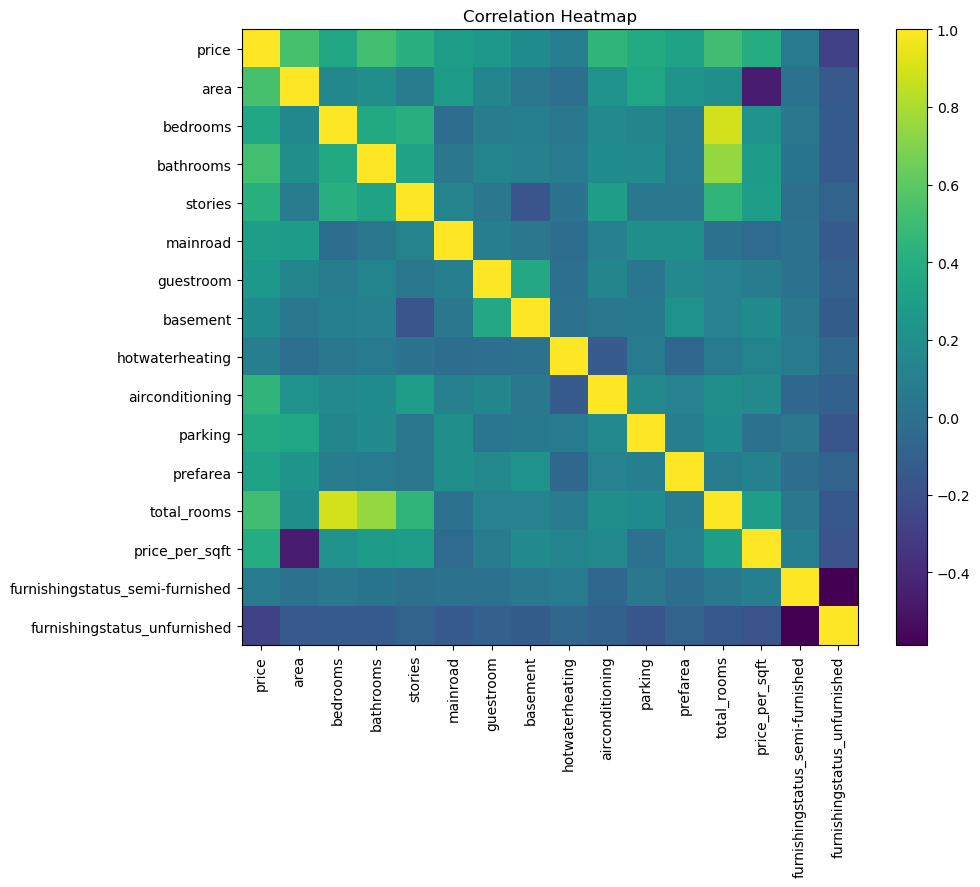

In [11]:
# Correlation heatmap
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()